In [1]:
import pandas as pd

xlsb_path = "2016cityandcountyenergyprofiles_units correction.xlsb"
sheet_name = "County"

header_info = pd.read_excel(xlsb_path, sheet_name=sheet_name, engine="pyxlsb", header=None, nrows=5).T
def build_composite_header(row):
    parts = [str(row[i]).strip().replace(" ", "_") for i in [1, 2, 4] if pd.notnull(row[i])]
    return "_".join(parts).lower()
composite_headers = header_info.apply(build_composite_header, axis=1).tolist()

df = pd.read_excel(xlsb_path, sheet_name=sheet_name, engine="pyxlsb", skiprows=4, header=None)
df.columns = composite_headers
df = df[df['state_id'] != 'state_id'].reset_index(drop=True)

selected_columns = [
    'state_id',
    'state_abbr',
    'county_state_name',
    'county_id',
    'county_name',
    'latitude',
    'longitude',
    'population',
    'residential_electricity_consumption_(mwh)',
    "residential_electricity_expenditures_('000_$)",
    'residential_occuped_housing_units',
    'commercial_electricity_consumption_(mwh)',
    "commercial_electricity_expenditures_('000_$)",
    'commercial_electricity_utility_customers',
    'residential_natural_gas_consumption_(mcf)',
    "residential_natural_gas_expenditures_('000_$)",
    'residential_natural_gas_utility_customers',
    'commercial_natural_gas_consumption_(mcf)',
    "commercial_natural_gas_expenditures_('000_$)",
    'commercial_natural_gas_utility_customers'
]

df_selected = df[selected_columns].copy()
df_selected['industry_electricity_consumption_(mwh)'] = df.iloc[:, 47]
df_selected["industry_electricity_expenditures_('000_$)"] = df.iloc[:, 48]
df_selected['industry_natural_gas_consumption_(mcf)'] = df.iloc[:, 51]
df_selected["industry_natural_gas_expenditures_('000_$)"] = df.iloc[:, 52]

output_file = "county_energy_with_natural_gas_and_industry.csv"
df_selected.to_csv(output_file, index=False)
print(f"✅ File saved as: {output_file}")

✅ File saved as: county_energy_with_natural_gas_and_industry.csv


In [2]:
import pandas as pd

df = pd.read_csv("county_energy_with_natural_gas_and_industry.csv")

MWH_TO_MMBTU = 3.412
MCF_TO_MMBTU = 1.037
THOUSAND_TO_ONE = 1000

df["residential_energy_mmbtu"] = (
    df["residential_electricity_consumption_(mwh)"] * MWH_TO_MMBTU +
    df["residential_natural_gas_consumption_(mcf)"] * MCF_TO_MMBTU
)

df["commercial_energy_mmbtu"] = (
    df["commercial_electricity_consumption_(mwh)"] * MWH_TO_MMBTU +
    df["commercial_natural_gas_consumption_(mcf)"] * MCF_TO_MMBTU
)

df["industrial_energy_mmbtu"] = (
    df["industry_electricity_consumption_(mwh)"] * MWH_TO_MMBTU +
    df["industry_natural_gas_consumption_(mcf)"] * MCF_TO_MMBTU
)

df["total_site_energy_mmbtu"] = (
    df["residential_energy_mmbtu"] +
    df["commercial_energy_mmbtu"] +
    df["industrial_energy_mmbtu"]
)

df["site_energy_per_capita_mmbtu"] = df["total_site_energy_mmbtu"] / df["population"]

df["residential_cost_usd"] = (
    df["residential_electricity_expenditures_('000_$)"] +
    df["residential_natural_gas_expenditures_('000_$)"]
) * THOUSAND_TO_ONE

df["commercial_cost_usd"] = (
    df["commercial_electricity_expenditures_('000_$)"] +
    df["commercial_natural_gas_expenditures_('000_$)"]
) * THOUSAND_TO_ONE

df["industrial_cost_usd"] = (
    df["industry_electricity_expenditures_('000_$)"] +
    df["industry_natural_gas_expenditures_('000_$)"]
) * THOUSAND_TO_ONE

df["total_energy_cost_usd"] = (
    df["residential_cost_usd"] +
    df["commercial_cost_usd"] +
    df["industrial_cost_usd"]
)

df["energy_cost_per_capita_usd"] = df["total_energy_cost_usd"] / df["population"]

simplified_df = df[[
    "state_abbr",
    "county_name",
    "latitude",
    "longitude",
    "total_site_energy_mmbtu",
    "site_energy_per_capita_mmbtu",
    "total_energy_cost_usd",
    "energy_cost_per_capita_usd",
    "population"
]]


simplified_df.to_csv("county_level_energy_metrics_simplified.csv", index=False)
print("Saved: county_level_energy_metrics_simplified.csv")


df_state = df.groupby("state_abbr").agg({
    "population": "sum",
    "total_site_energy_mmbtu": "sum",
    "total_energy_cost_usd": "sum"
}).reset_index()

df_state["site_energy_per_capita_mmbtu"] = (
    df_state["total_site_energy_mmbtu"] / df_state["population"]
)

df_state["energy_cost_per_capita_usd"] = (
    df_state["total_energy_cost_usd"] / df_state["population"]
)

state_output_path = "state_level_energy_metrics.csv"
df_state.to_csv(state_output_path, index=False)

print(f"State-level data saved to: {state_output_path}")

Saved: county_level_energy_metrics_simplified.csv
State-level data saved to: state_level_energy_metrics.csv


## 📄 CSV Columns Guide – Energy Data Preparation

This notebook generates three CSV files at different stages of the data preparation process. Each CSV serves a specific purpose and contains different levels of detail. Below is a breakdown of what each file includes and how to interpret its columns.

---

### 🔹 1. `county_energy_with_natural_gas_and_industry.csv`
**Purpose**: A detailed county-level dataset combining electricity and natural gas consumption + expenditure for both the residential and commercial sectors.

**Columns:**

| Column Name | Description |
|-------------|-------------|
| `state_id` | FIPS numeric code for the state |
| `state_abbr` | Two-letter state abbreviation (e.g., `IN`) |
| `county_state_name` | Full label combining county and state name (e.g., `Wayne County, IN`) |
| `county_id` | FIPS code for the county |
| `county_name` | Name of the county |
| `latitude` | Geographic latitude of the county's centroid |
| `longitude` | Geographic longitude of the county's centroid |
| `population` | Total population of the county |
| `residential_occuped_housing_units` | Number of occupied residential housing units |
| `residential_electricity_consumption_(mwh)` | Residential electricity use in megawatt-hours (MWh) |
| `residential_electricity_expenditures_('000_$)` | Residential electricity spending in thousands of USD |
| `residential_natural_gas_consumption_(mcf)` | Residential natural gas use in thousand cubic feet (MCF) |
| `residential_natural_gas_expenditures_('000_$)` | Residential natural gas spending in thousands of USD |
| `residential_natural_gas_utility_customers` | Number of residential natural gas customers |
| `commercial_electricity_consumption_(mwh)` | Commercial electricity use in MWh |
| `commercial_electricity_expenditures_('000_$)` | Commercial electricity spending in thousands of USD |
| `commercial_electricity_utility_customers` | Number of commercial electricity customers |
| `commercial_natural_gas_consumption_(mcf)` | Commercial natural gas use in MCF |
| `commercial_natural_gas_expenditures_('000_$)` | Commercial natural gas spending in thousands of USD |
| `commercial_natural_gas_utility_customers` | Number of commercial natural gas customers |

---

### 🔹 2. `county_level_energy_metrics_simplified.csv`
**Purpose**: A simplified and clean county-level summary with key computed metrics for energy usage and cost. Designed for visualization and basic comparison.

**Columns:**

| Column Name | Description |
|-------------|-------------|
| `state_abbr` | Two-letter state abbreviation |
| `county_name` | Name of the county |
| `latitude` | Geographic latitude |
| `longitude` | Geographic longitude |
| `total_site_energy_mmbtu` | Combined energy usage (electricity + natural gas) converted to MMBTU |
| `site_energy_per_capita_mmbtu` | Per capita energy use in MMBTU |
| `total_energy_cost_usd` | Total energy cost in US dollars |
| `energy_cost_per_capita_usd` | Energy cost per resident in US dollars |
| `population` | County population |

---

### 🔹 3. `state_level_energy_metrics.csv`
**Purpose**: Aggregated state-level metrics derived from county data. Useful for macro-scale energy comparisons.

**Columns:**

| Column Name | Description |
|-------------|-------------|
| `state_abbr` | Two-letter state abbreviation |
| `total_site_energy_mmbtu` | Total energy use (in MMBTU) summed across all counties in the state |
| `site_energy_per_capita_mmbtu` | Average energy use per person in MMBTU |
| `total_energy_cost_usd` | Total statewide energy expenditure in USD |
| `energy_cost_per_capita_usd` | Average energy cost per resident in USD |
| `population` | Total state population |

---


In [3]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import plotly.colors as pc

df = pd.read_csv("state_level_energy_metrics.csv")

viridis = pc.sequential.Viridis
plasma = pc.sequential.Plasma
analogous_palette = pc.sequential.YlOrRd

fig = make_subplots(
    rows=2, cols=2,
    column_widths=[0.5, 0.5],
    row_heights=[0.5, 0.5],
    specs=[
        [{"type": "choropleth"}, {"type": "choropleth", "rowspan": 2}],
        [{"type": "choropleth"}, {"type": "scattergeo"}]
    ],
    subplot_titles=("Population", "Per Capita Energy Use", "Total Energy Consumption")
)

fig.add_trace(
    go.Choropleth(
        locations=df["state_abbr"],
        z=df["population"],
        locationmode="USA-states",
        colorscale=analogous_palette,
        colorbar_title="Population",
        name="Population",
        colorbar=dict(x=0.45, y=0.75, len=0.4)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Choropleth(
        locations=df["state_abbr"],
        z=df["total_site_energy_mmbtu"],
        locationmode="USA-states",
        colorscale=plasma,
        colorbar_title="MMBTU",
        name="Total Energy",
        colorbar=dict(x=0.45, y=0.25, len=0.4)
    ),
    row=2, col=1
)

fig.add_trace(
    go.Choropleth(
        locations=df["state_abbr"],
        z=df["site_energy_per_capita_mmbtu"],
        locationmode="USA-states",
        colorscale=viridis,
        colorbar_title="MMBTU",
        name="Energy/Capita",
        colorbar=dict(x=1.0, y=0.5, len=0.9)
    ),
    row=1, col=2
)

warmest_states = ['FL', 'LA', 'TX', 'HI', 'MS', 'GA', 'AL', 'SC', 'AR', 'OK']
coldest_states = ['AK', 'ND', 'WY', 'MT', 'ME', 'MN', 'VT', 'NH', 'WI', 'CO']

state_centroids = {
    'FL': (-81.5158, 27.6648),
    'LA': (-92.0198, 30.9843),
    'TX': (-99.9018, 31.9686),
    'HI': (-155.5828, 19.8968),
    'MS': (-89.3985, 32.3547),
    'GA': (-82.9071, 32.1656),
    'AL': (-86.9023, 32.3182),
    'SC': (-81.1637, 33.8361),
    'AR': (-92.3731, 34.7465),
    'OK': (-97.0929, 35.0078),
    'AK': (-152.4044, 61.3707),
    'ND': (-99.9018, 47.5515),
    'WY': (-107.2903, 43.0759),
    'MT': (-110.3626, 46.8797),
    'ME': (-69.4455, 45.2538),
    'MN': (-94.6859, 46.7296),
    'VT': (-72.5778, 43.8718),
    'NH': (-71.5724, 43.1939),
    'WI': (-88.7879, 43.7844),
    'CO': (-105.7821, 39.5501)
}

warm_lons = [state_centroids[s][0] for s in warmest_states]
warm_lats = [state_centroids[s][1] for s in warmest_states]
cold_lons = [state_centroids[s][0] for s in coldest_states]
cold_lats = [state_centroids[s][1] for s in coldest_states]

fig.add_trace(
    go.Scattergeo(
        mode='markers',
        lon=warm_lons,
        lat=warm_lats,
        marker=dict(
            symbol='star',
            color='orangered',
            size=12,
            opacity=1,  
            line=dict(width=1, color='black')
        ),
        name='10 Warmest States'
    ),
    row=1, col=2
)

fig.add_trace(
    go.Scattergeo(
        mode='markers',
        lon=cold_lons,
        lat=cold_lats,
        marker=dict(
            symbol='asterisk',
            color='deepskyblue',
            size=13,
            line=dict(width=2.2, color='deepskyblue')
        ),
        name='10 Coldest States'
    ),
    row=1, col=2
)

fig.update_layout(
    geo=dict(
        projection=dict(
            type="albers usa"
        ),
        scope="usa" 
    ),
    geo2=dict(
        projection=dict(
            type="albers usa"
        ),
        scope="usa" 
    ),
    geo3=dict(
        projection=dict(
            type="albers usa"
        ),
        scope="usa" 
    ),
    title_text="U.S. States: Population, Total Energy Use, and Per Capita Energy Use (2016)",
    height=900,
    width=1050
)

fig.show()

In [4]:
import plotly.io as pio

fig.write_image("plot_image.png") 

Choropleth Population (Detail)

In [5]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import plotly.colors as pc

df = pd.read_csv("state_level_energy_metrics.csv")

analogous_palette = pc.sequential.YlOrRd

fig = make_subplots(
    rows=1, cols=1,
    specs=[[{"type": "choropleth"}]],
    subplot_titles=("Population",)
)

fig.add_trace(
    go.Choropleth(
        locations=df["state_abbr"],
        z=df["population"],
        locationmode="USA-states",
        colorscale=analogous_palette,
        colorbar_title="Population",
        name="Population",
        colorbar=dict(x=0.9, y=0.5, len=0.4)
    ),
    row=1, col=1
)

fig.update_layout(
    geo=dict(
        projection=dict(
            type="albers usa"
        ),
        scope="usa" 
    ),
    title_text="U.S. States: Population (2016)",
    height=600,
    width=800
)

fig.show()


Choropleth Total Energy Consumption (Detail)

In [6]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import plotly.colors as pc

df = pd.read_csv("state_level_energy_metrics.csv")

plasma = pc.sequential.Plasma

fig = make_subplots(
    rows=1, cols=1,
    specs=[[{"type": "choropleth"}]],
    subplot_titles=("Total Energy Consumption",)
)

fig.add_trace(
    go.Choropleth(
        locations=df["state_abbr"],
        z=df["total_site_energy_mmbtu"],
        locationmode="USA-states",
        colorscale=plasma,
        colorbar_title="MMBTU",
        name="Total Energy",
        colorbar=dict(x=0.85, y=0.25, len=0.4) 
    ),
    row=1, col=1
)

fig.update_layout(
    geo=dict(
        projection=dict(
            type="albers usa"
        ),
        scope="usa" 
    ),
    title_text="U.S. States: Total Energy Use (2016)",
    height=600,
    width=800
)

fig.show()

Choropleth Per CapitaEnergy Consumption (Detail)

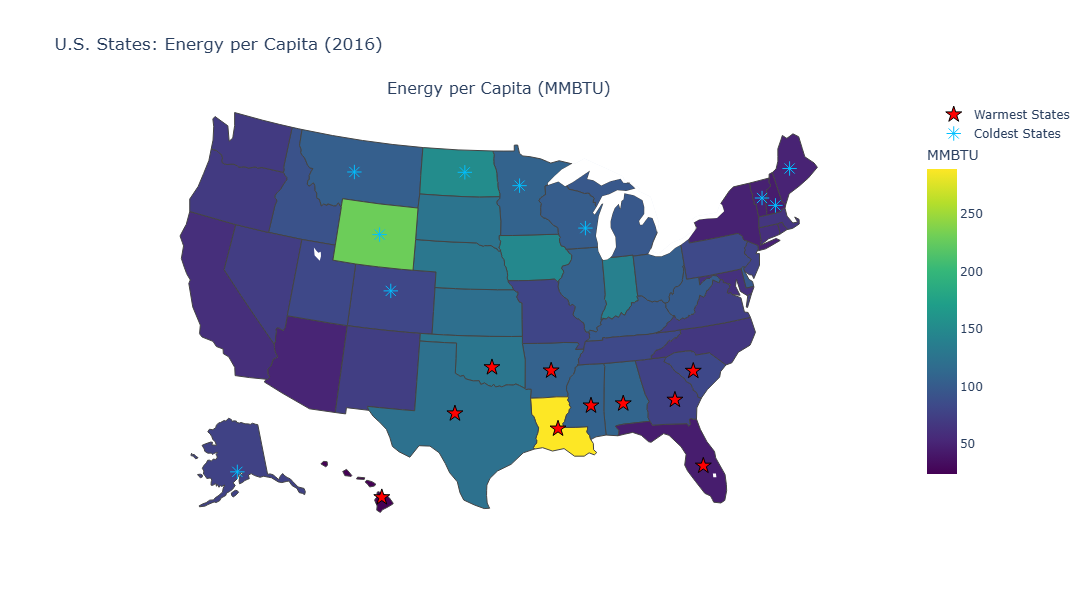

In [7]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import plotly.colors as pc

df = pd.read_csv("state_level_energy_metrics.csv")

viridis = pc.sequential.Viridis

warmest_states = ['FL', 'LA', 'TX', 'HI', 'MS', 'GA', 'AL', 'SC', 'AR', 'OK']
coldest_states = ['AK', 'ND', 'WY', 'MT', 'ME', 'MN', 'VT', 'NH', 'WI', 'CO']

state_centroids = {
    'FL': (-81.5158, 27.6648),
    'LA': (-92.0198, 30.9843),
    'TX': (-99.9018, 31.9686),
    'HI': (-155.5828, 19.8968),
    'MS': (-89.3985, 32.3547),
    'GA': (-82.9071, 32.1656),
    'AL': (-86.9023, 32.3182),
    'SC': (-81.1637, 33.8361),
    'AR': (-92.3731, 34.7465),
    'OK': (-97.0929, 35.0078),
    'AK': (-152.4044, 61.3707),
    'ND': (-99.9018, 47.5515),
    'WY': (-107.2903, 43.0759),
    'MT': (-110.3626, 46.8797),
    'ME': (-69.4455, 45.2538),
    'MN': (-94.6859, 46.7296),
    'VT': (-72.5778, 43.8718),
    'NH': (-71.5724, 43.1939),
    'WI': (-88.7879, 43.7844),
    'CO': (-105.7821, 39.5501)
}

warm_lons = [state_centroids[s][0] for s in warmest_states]
warm_lats = [state_centroids[s][1] for s in warmest_states]
cold_lons = [state_centroids[s][0] for s in coldest_states]
cold_lats = [state_centroids[s][1] for s in coldest_states]

fig = make_subplots(
    rows=1, cols=1,
    specs=[[{"type": "choropleth"}]],
    subplot_titles=("Energy per Capita (MMBTU)",)
)

fig.add_trace(
    go.Choropleth(
        locations=df["state_abbr"],
        z=df["site_energy_per_capita_mmbtu"],
        locationmode="USA-states",
        colorscale=viridis,
        colorbar_title="MMBTU",
        name="Energy/Capita",
        colorbar=dict(x=1.0, y=0.5, len=0.825)  
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scattergeo(
        mode='markers',
        lon=warm_lons,
        lat=warm_lats,
        marker=dict(
            symbol='star',
            color='red',
            size=12,
            opacity=1,
            line=dict(width=1, color='black')
        ),
        name='Warmest States'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scattergeo(
        mode='markers',
        lon=cold_lons,
        lat=cold_lats,
        marker=dict(
            symbol='asterisk',
            color='blue',
            size=12,
            opacity=1,
            line=dict(width=1, color='deepskyblue')
        ),
        name='Coldest States'
    ),
    row=1, col=1
)

fig.update_layout(
    geo=dict(
        projection=dict(
            type="albers usa"
        ),
        scope="usa"
    ),
    title_text="U.S. States: Energy per Capita (2016)",
    height=600,
    width=800
)

fig.show()
